<a href="https://colab.research.google.com/github/rawanahmedashraf-blip/hidden-gaps-students-opportunities/blob/main/notebooks/gap_analysisphase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMPLETE SKILL GAP ANALYSIS (Phase 2)
           Skill  Market Demand %  Student Supply %  Gap Score %       Gap Type
   Visualization             80.9              76.0          4.9 MINOR SHORTAGE
         Tableau             30.2              33.8         -3.6   OVERSUPPLIED
             SQL             54.9              70.2        -15.3   OVERSUPPLIED
Machine Learning             34.0              52.4        -18.4   OVERSUPPLIED
          Python             40.4              63.6        -23.2   OVERSUPPLIED
        Power BI             45.1              72.0        -26.9   OVERSUPPLIED
      Statistics             55.7              83.1        -27.4   OVERSUPPLIED
           Excel             48.5              89.8        -41.3   OVERSUPPLIED


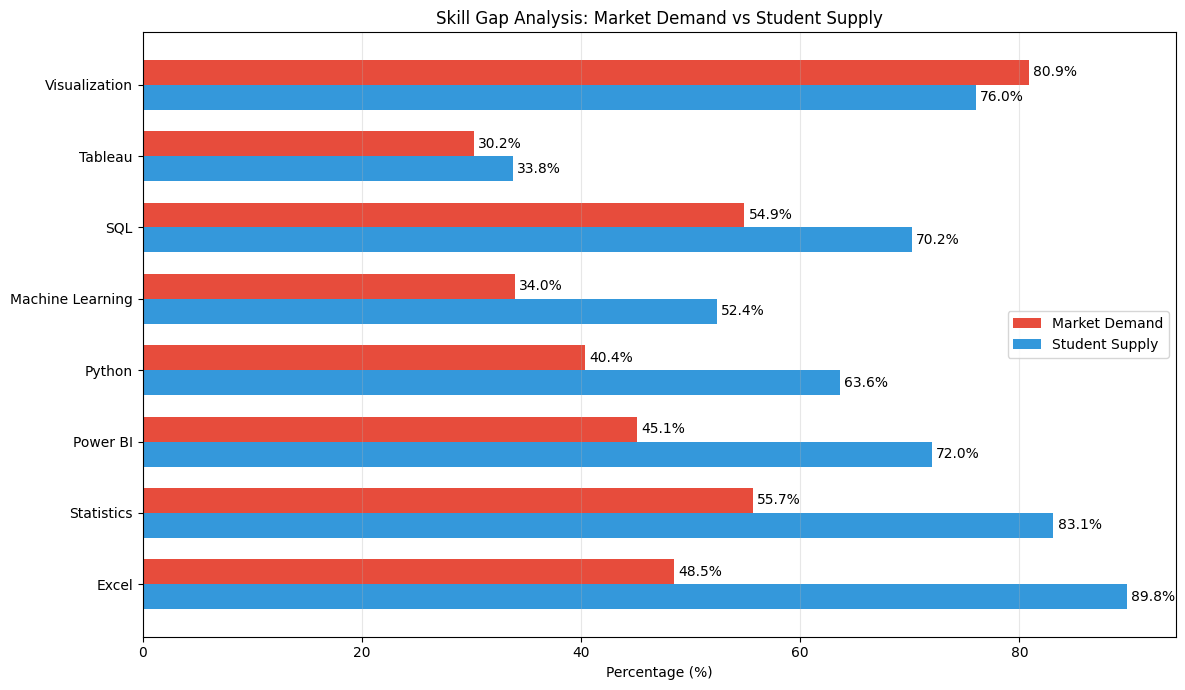

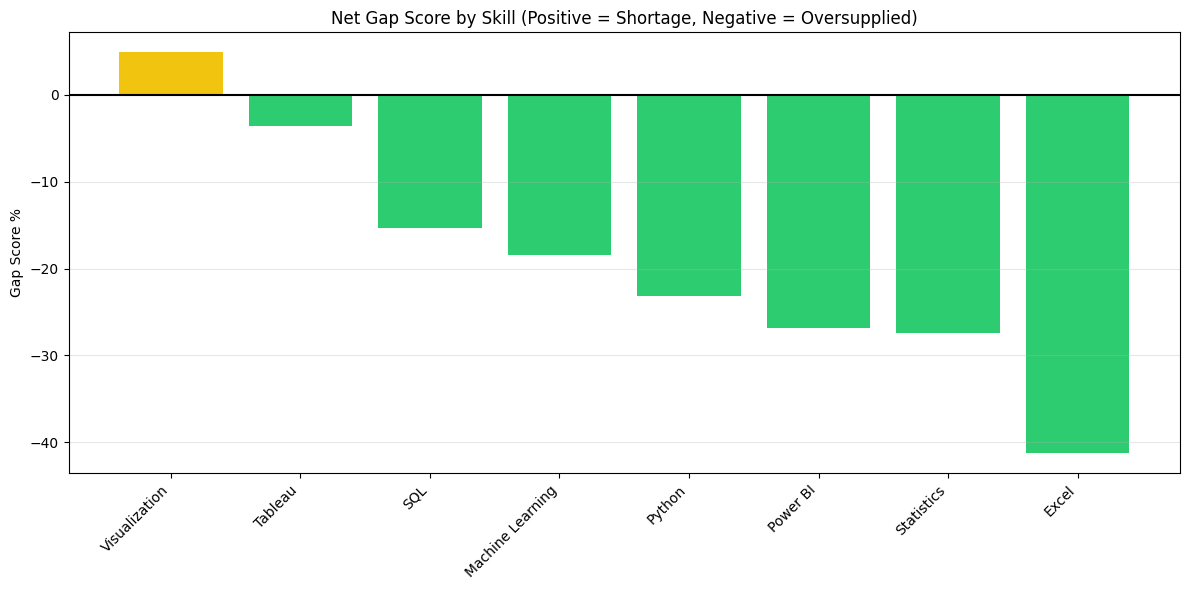

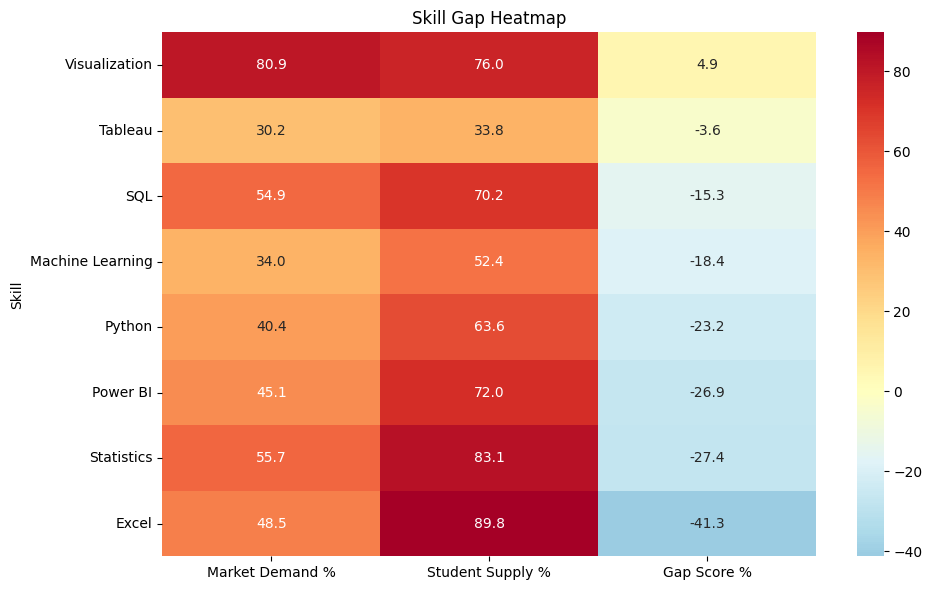


🔥 KEY INSIGHTS:
- MINOR SHORTAGE: Visualization (Gap: 4.9%) → Must prioritize.

⚠️ OVERSUPPLIED SKILLS:
- Tableau (Gap: -3.6%) → Students are over-investing compared to entry-level demand.
- SQL (Gap: -15.3%) → Students are over-investing compared to entry-level demand.
- Machine Learning (Gap: -18.4%) → Students are over-investing compared to entry-level demand.
- Python (Gap: -23.2%) → Students are over-investing compared to entry-level demand.
- Power BI (Gap: -26.9%) → Students are over-investing compared to entry-level demand.
- Statistics (Gap: -27.4%) → Students are over-investing compared to entry-level demand.
- Excel (Gap: -41.3%) → Students are over-investing compared to entry-level demand.

✅ Phase 2 Complete. Files Saved: CSV + 3 PNGs.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------------------------------
# 1. LOAD DATA (استخدام الملفات الجاهزة كما تنص الخطة)
# -----------------------------------------------------
supply_df = pd.read_csv('student_skill_supply_COMPLETE_v3.csv')
demand_df = pd.read_csv('job_market_demand_COMPLETE_v2.csv')
# -----------------------------------------------------
# 2. DEFINE SKILL MAPPING
# -----------------------------------------------------
skill_mapping = {
    'Python': 'python_required',
    'SQL': 'sql_required',
    'Excel': 'excel_required',
    'Statistics': 'statistics_required',
    'Power BI': 'powerbi_required',
    'Tableau': 'tableau_required',
    'Visualization (General)': 'any_viz_required',
    'Machine Learning': 'ml_required'
}

# -----------------------------------------------------
# 3. MERGE & CALCULATE GAP
# -----------------------------------------------------
merged_data = []

for sup_name, dem_name in skill_mapping.items():
    supply_val = supply_df[supply_df['Skill'] == sup_name]['Student Supply %'].values
    demand_val = demand_df[demand_df['Skill'] == dem_name]['Market Demand %'].values

    if len(supply_val) > 0 and len(demand_val) > 0:
        supply = float(supply_val[0])
        demand = float(demand_val[0])
        gap = round(demand - supply, 1)

        # Classification
        if gap >= 30:
            gap_type = 'CRITICAL SHORTAGE'
        elif gap >= 15:
            gap_type = 'MODERATE SHORTAGE'
        elif gap >= 0:
            gap_type = 'MINOR SHORTAGE'
        else:
            gap_type = 'OVERSUPPLIED'

        # Clean display name
        display_name = sup_name.replace(' (General)', '')

        merged_data.append({
            'Skill': display_name,
            'Market Demand %': round(demand, 1),
            'Student Supply %': round(supply, 1),
            'Gap Score %': gap,
            'Gap Type': gap_type
        })

gap_df = pd.DataFrame(merged_data)
gap_df = gap_df.sort_values(by='Gap Score %', ascending=False)

# -----------------------------------------------------
# 4. SAVE OUTPUT
# -----------------------------------------------------
gap_df.to_csv('gap_analysis_FINAL.csv', index=False)
print("="*70)
print("COMPLETE SKILL GAP ANALYSIS (Phase 2)")
print("="*70)
print(gap_df.to_string(index=False))

# -----------------------------------------------------
# 5. VISUALIZATION 1: SIDE BY SIDE
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(gap_df))
h = 0.35

bars1 = ax.barh(y - h/2, gap_df['Market Demand %'], h, label='Market Demand', color='#e74c3c')
bars2 = ax.barh(y + h/2, gap_df['Student Supply %'], h, label='Student Supply', color='#3498db')

ax.set_yticks(y)
ax.set_yticklabels(gap_df['Skill'])
ax.set_xlabel("Percentage (%)")
ax.set_title("Skill Gap Analysis: Market Demand vs Student Supply")
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.bar_label(bars2, fmt='%.1f%%', padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("gap_side_by_side.png", dpi=300)
plt.show()

# -----------------------------------------------------
# 6. VISUALIZATION 2: GAP COLOR CHART (زميلك)
# -----------------------------------------------------
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x >= 30 else
          '#f39c12' if x >= 15 else
          '#f1c40f' if x >= 0 else
          '#2ecc71' for x in gap_df['Gap Score %']]

bars = plt.bar(gap_df['Skill'], gap_df['Gap Score %'], color=colors)
plt.axhline(0, color='black', linewidth=1.5)
plt.title("Net Gap Score by Skill (Positive = Shortage, Negative = Oversupplied)")
plt.ylabel("Gap Score %")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("gap_score_waterfall.png", dpi=300)
plt.show()

# -----------------------------------------------------
# 7. VISUALIZATION 3: HEATMAP (زميلك)
# -----------------------------------------------------
plt.figure(figsize=(10, 6))
# إعداد البيانات للخريطة الحرارية
heat_df = gap_df.set_index('Skill')[['Market Demand %', 'Student Supply %', 'Gap Score %']]
sns.heatmap(heat_df, annot=True, cmap='RdYlBu_r', fmt=".1f", center=0)
plt.title("Skill Gap Heatmap")
plt.tight_layout()
plt.savefig("gap_heatmap.png", dpi=300)
plt.show()

# -----------------------------------------------------
# 8. INSIGHTS AUTO-GENERATION
# -----------------------------------------------------
print("\n🔥 KEY INSIGHTS:")
top_gaps = gap_df[gap_df['Gap Type'].str.contains('SHORTAGE')].head(3)
for _, row in top_gaps.iterrows():
    print(f"- {row['Gap Type']}: {row['Skill']} (Gap: {row['Gap Score %']}%) → Must prioritize.")

oversupply = gap_df[gap_df['Gap Type'] == 'OVERSUPPLIED']
if not oversupply.empty:
    print("\n⚠️ OVERSUPPLIED SKILLS:")
    for _, row in oversupply.iterrows():
        print(f"- {row['Skill']} (Gap: {row['Gap Score %']}%) → Students are over-investing compared to entry-level demand.")

print("\n✅ Phase 2 Complete. Files Saved: CSV + 3 PNGs.")

In [2]:
import os
print(os.listdir())

['.config', 'student_skill_supply_COMPLETE_v3.csv', 'job_market_demand_COMPLETE_v2.csv', 'sample_data']
